# 08 — Model Analysis

Analyses and compares the performance of all fitted ML models. Produces the model comparison figures in the paper.

## Prerequisites / Input files
- `Fe-Mo/results/voting_regressor_*.pkl` — ensemble models (built by notebook 07)
- `Fe-Mo/results/concatenation_results_*.pkl`

## Outputs
- `Fe-Mo/graphs/` — model comparison and feature importance figures



# Results over the learning set

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from fontTools.ttLib.tables._p_r_e_p import table__p_r_e_p

from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
try:
    from dependencies.bopdftprojections.bopdftprojections.projections import Projections
    _has_bopdftprojections = True
except (ModuleNotFoundError, ImportError):
    _has_bopdftprojections = False
from Tools.DatasetTools.DatasetOperator import  Dataset
from Tools.DatasetTools.Tools import  Plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
target_case = 'EF_nmhcp'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')
from Tools.DatasetTools.MLConveniences import filter_features
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, linregress
from sklearn.metrics import r2_score

/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from matplotlib.lines import Line2D
plt.rc('font', size=18)
plt.rc('xtick', labelsize=22)
plt.rc('ytick', labelsize=22)
plt.rc('lines', linewidth=3)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('axes', labelsize=24)

# Methods

In [3]:
def make_feature_labels(feature_name):
    for label in ['BOP', 'ACE', 'SOAP']:
        if label in feature_name:
            return label
    if 'dataset' in feature_name:
        return 'structure encoding'
    return feature_name

In [4]:
def make_phase_label(phase_name):
    if 'sigma' in phase_name or 'mu' in phase_name or 'chi' in phase_name:
        return rf'$\{phase_name}$'
    return phase_name

# Parameters

In [5]:
ModelName = 'Kernel Ridge'
modelname = ModelName.replace(' ','')
featurenames = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE' }

# Load dataset

In [6]:
DS = Dataset(
    dataset=dataset,
    target_name=target_case,
    remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"',
    load_features_only = ['0.7dProjections 0.5OS BOP', 'ACE', 'SOAP_specific_small', 'dataset']
    )
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]

In [7]:
P = Plotting()

In [8]:
CHULL = {}
for phase, bs_phase in BS.groupby(by='Phase'):
    if phase == 'R':
        continue
    CHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp'))

In [9]:
train_features = DS.Features

In [10]:
colors = sns.color_palette('bright', len(CHULL))

# LOAD MODELS 

In [11]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_{modelname}.pkl')

In [12]:
voting_regressor = joblib.load(regressor_file)

In [13]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV')])

In [14]:
voting_regressor[('Kernel Ridge', '0.7dProjections 0.5OS BOP')]

VotingRegressor(estimators=[('0',
                             Pipeline(steps=[['feature_selection',
                                              FunctionTransformer(func=<function filter_features at 0x7f54b5ba0220>,
                                                                  kw_args={'learning_curve':                          train1     test1   
Binf_0_0               0.092870  0.095046  \
sigma_3_CN16           0.068318  0.085065   
sigma_4_CN12           0.043628  0.064004   
sigma_13_0             0.029108  0.066195   
sigma_6_CN15           0.024004  0.064160   
...                         ...       ...   
bn_4_0                 0.000062  0.052795   
bn_1_CN14              0...
bn_3_0                 0.054189  0.053409  
bn_4_0                 0.051593  0.048493  
...                         ...       ...  
moments_2_CN15         0.018899  0.008142  
an_2_CN15              0.018852  0.008158  
normed_moments_3_0     0.018968  0.008169  
normed_moments_10_0    0.019140  0.008175  
sigma_14_CN12          0.019364  0.008186  

[185 rows x 5 columns],
                                                                           'remove_structure': True})],
                                             ('scaler', StandardScaler()),
                                             ('regressor',
                                              KernelRidge(alpha=0.1, degree=4,
                                                          kernel='polynomial'))]))])

# Prediction for the learning dataset

In [15]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV')])

In [16]:
predictionBS = DS.BS.copy()

In [17]:
DS.target_name

'EF_nmhcp'

In [18]:
Err = {}

In [19]:
indexsplit = DS.load_indexsplit(split_random_state=42, test_size=0.2)

# prediction - target correlations

In [20]:
rmse = {}
r2 = {}
mae = {}

In [21]:
for featurenames, feature in DS.Features.items():
    print(featurenames)
    prediction_name = f'{DS.target_name}_{ modelname }_{featurenames}'
    combi = (ModelName, featurenames)
    voting_regressor[combi].fit(feature.loc[indexsplit['train']], DS.BS[DS.target_name][indexsplit['train']])
    if prediction_name not in predictionBS:
        Y  = pd.Series(voting_regressor[combi].predict(feature), index = feature.index, name = prediction_name)
        predictionBS = pd.concat([predictionBS, Y], axis = 1)
    Err[combi] =(  predictionBS[prediction_name] - predictionBS[DS.target_name] ).abs().dropna()*1000
    rmse[combi]=np.sqrt((Err[combi][indexsplit['test']]**2).sum()/len(Err[combi][indexsplit['test']]))
    r2[combi] = r2_score(DS.BS[target_case][indexsplit['test']], predictionBS[prediction_name][indexsplit['test']])
    mae[combi] =  Err[combi][indexsplit['test']].mean()


0.7dProjections 0.5OS BOP
ACE
SOAP_specific_small
dataset


In [22]:
predictionBS = predictionBS.dropna()

# Prediction - target plots

In [23]:
regpolots_loc = os.path.join(dataset, 'graphs', 'reg_error_plots')

In [24]:
if not os.path.exists(regpolots_loc):
    os.makedirs(regpolots_loc)

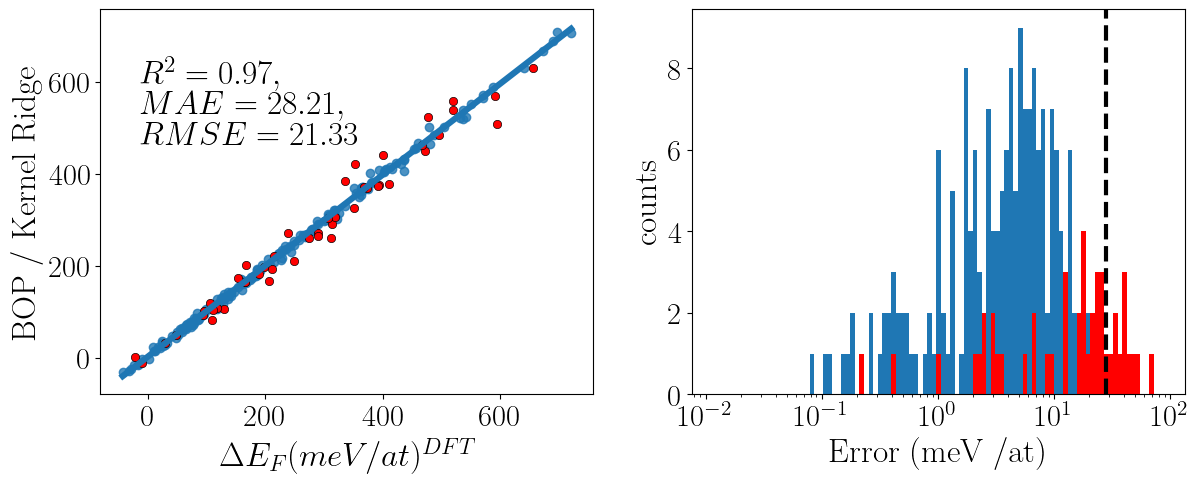

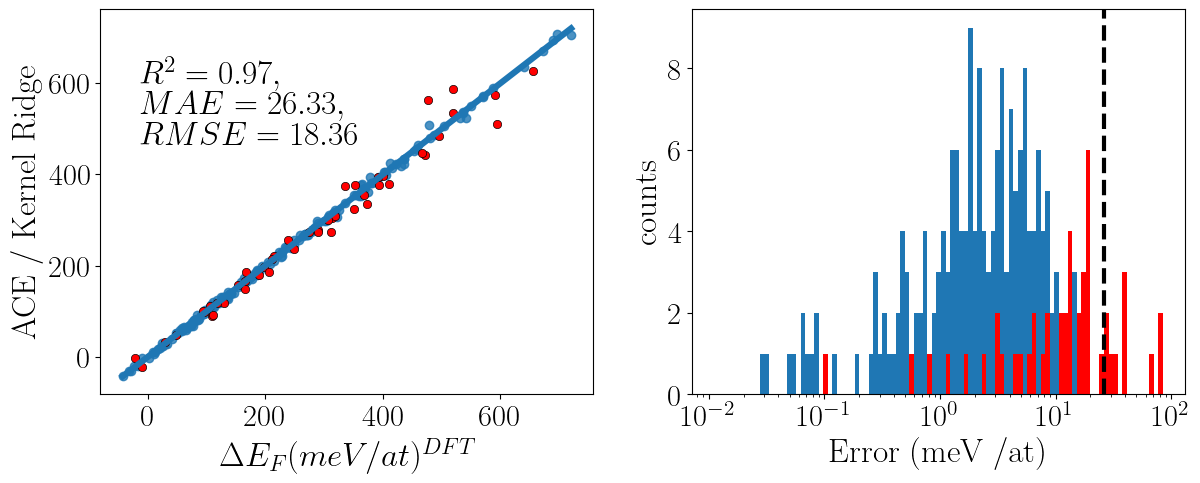

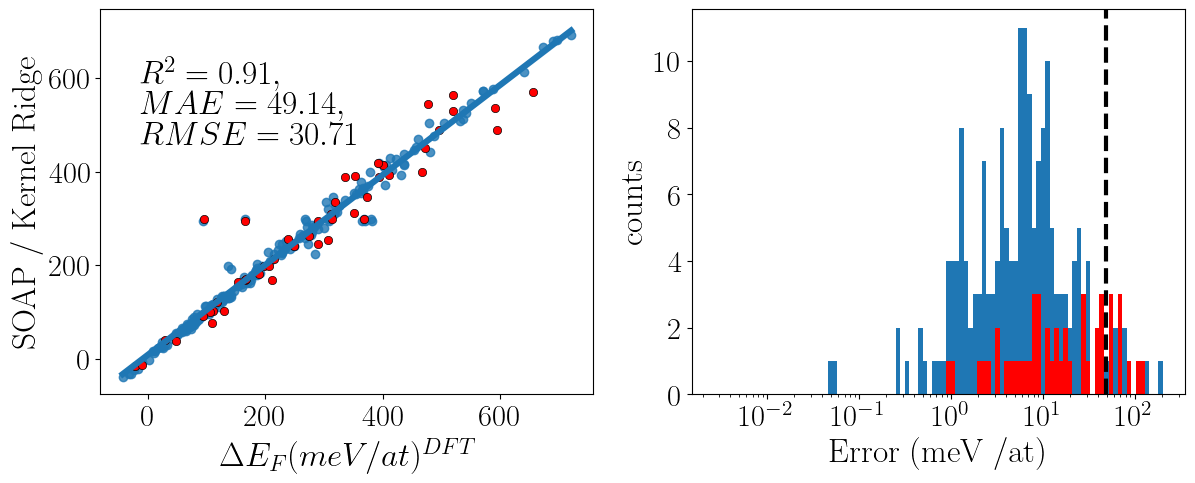

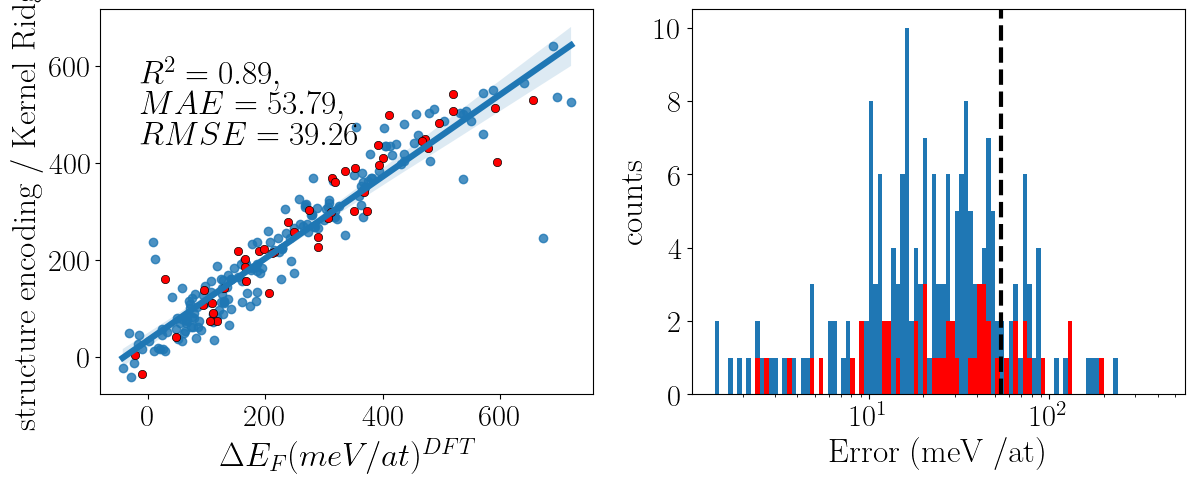

In [25]:
for featurenames, feature in DS.Features.items():
    filename = os.path.join(regpolots_loc, f'reg_error_plots_{dataset}_{modelname}_{featurenames}.pdf')
    prediction_name = f'{DS.target_name}_{ modelname }_{featurenames}'
    combi = (ModelName, featurenames)
    fig, ax = plt.subplots(1,2, figsize= [ plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1] ]  )
    log_bins = np.logspace(np.log10(Err[combi].min()), np.log10(Err[combi].max()), 100 )
    sns.regplot(x=DS.BS[target_case][indexsplit['train']]*1000, y = predictionBS[prediction_name][indexsplit['train']]*1000, ax = ax[0])
    sns.scatterplot(x=DS.BS[target_case][indexsplit['test']]*1000, y = predictionBS[prediction_name][indexsplit['test']]*1000, ax = ax[0], facecolor='red', edgecolor='k')
    ax[0].set_ylabel(make_feature_labels(prediction_name)+' / '+ModelName)
    ax[0].set_xlabel('$\Delta E_{F} (meV/at) ^{DFT}$')
    ax[1].hist(Err[combi][indexsplit['train']], bins=log_bins)
    ax[1].hist(Err[combi][indexsplit['test']], bins=log_bins, color='red')
    ax[1].axvline(rmse[combi],ls='--',c='k')
    ax[1].annotate(r'$\\R^2 = {:.2f},\\MAE={:.2f},\\RMSE={:.2f}$'.format(r2[combi], rmse[combi], mae[combi]), (0.1, 0.8), xycoords='figure fraction' )
    ax[1].set_xscale('log')
    ax[1].set_ylabel ('counts')
    ax[1].set_xlabel('Error (meV /at)')
    fig.savefig(filename)
#    sns.histplot(x=E[combi], bins=log_bins, log_scale='x', ax = ax[1])

# convex hulls

In [26]:
predicted_targets = predictionBS.filter(regex=modelname).columns

In [27]:
PREDICT_CHULL = {}
phase_predictionBS = {}
for phase, predict_bs_phase in predictionBS.groupby(by='Phase'):
    if phase == 'R':
        continue
    phase_predictionBS[phase] = predict_bs_phase

In [28]:
for predicted_target in predicted_targets:
    PREDICT_CHULL[predicted_target] = {}
    for phase, predict_bs_phase in phase_predictionBS.items():
        PREDICT_CHULL[predicted_target].update(
            P.get_convex_hulls({phase: predict_bs_phase}, ['Fe', 'Mo'],getproperty=predicted_target)
        )

In [29]:
convexull_plots_loc = os.path.join(dataset, 'graphs', 'convex_hull_plots')

In [30]:
if not os.path.exists(convexull_plots_loc):
    os.makedirs(convexull_plots_loc)

In [31]:
predictionBS.columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'Mag', 'Phase', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc',
       'EF_nmhcp_KernelRidge_0.7dProjections 0.5OS BOP',
       'EF_nmhcp_KernelRidge_ACE', 'EF_nmhcp_KernelRidge_SOAP_specific_small',
       'EF_nmhcp_KernelRidge_dataset'],
      dtype='object')

In [32]:
predicted_targets=predictionBS.filter(regex=modelname).columns

In [33]:
xy_chull = {}
#fig, ax = plt.subplots(figsize=(12, 8))
for phase, chull in CHULL.items():
    if phase in ['bcc', 'fcc', 'hcp', 'R']:
        continue
    bs_phase = BS[BS.Phase == phase]
    vertices = np.unique(chull.simplices[chull.good])
    xy_chull[phase] = bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')

In [34]:
Err[('Kernel Ridge',  '0.7dProjections 0.5OS BOP')]

Fe_pv4Mo_sv20.C36-ABBBB.FM         22.766026
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM     0.173147
Fe_pv2Mo_sv11.mu-BBABB.FM           3.884003
Fe_pv8Mo_sv22.sigma-BBBAB.NM        6.466219
Fe_pv2Mo_sv11.mu-BBBBA.NM           6.456326
                                     ...    
Mo_sv29.chi.FM                      4.177907
Fe_pv4Mo_sv2.C15-A2B.FM             0.798412
Fe_pv8Mo_sv16.C36-BAABB.NM          5.627871
Mo_sv8.A15.NM                       5.482557
Mo_sv6.C15.NM                       3.072770
Length: 234, dtype: float64

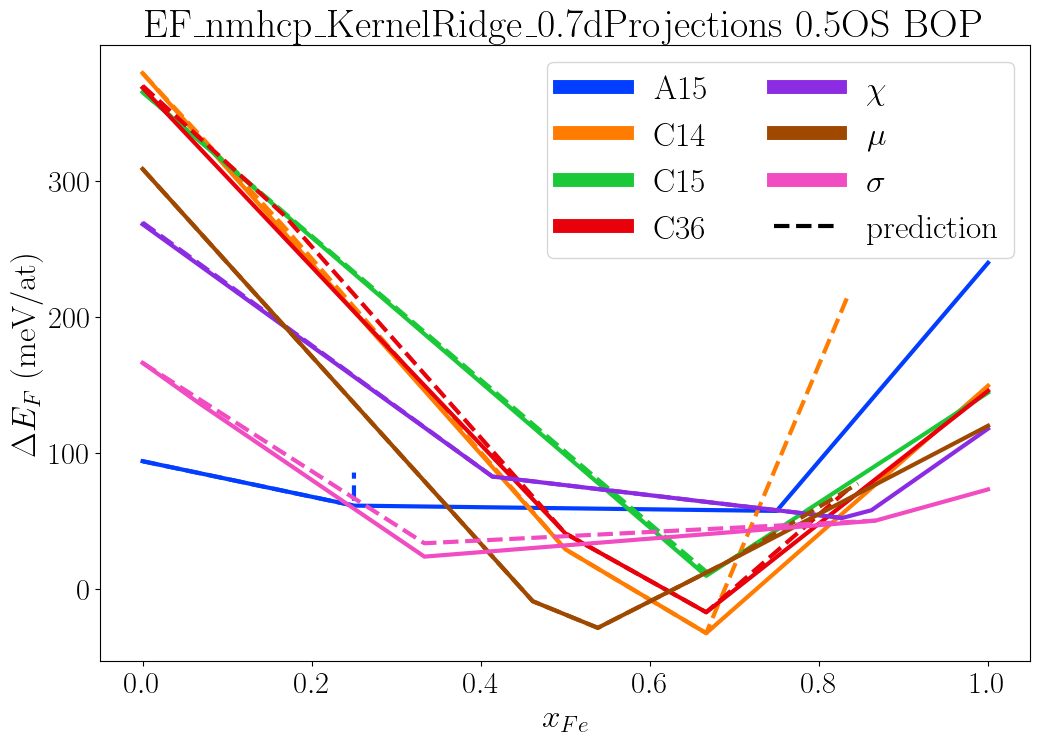

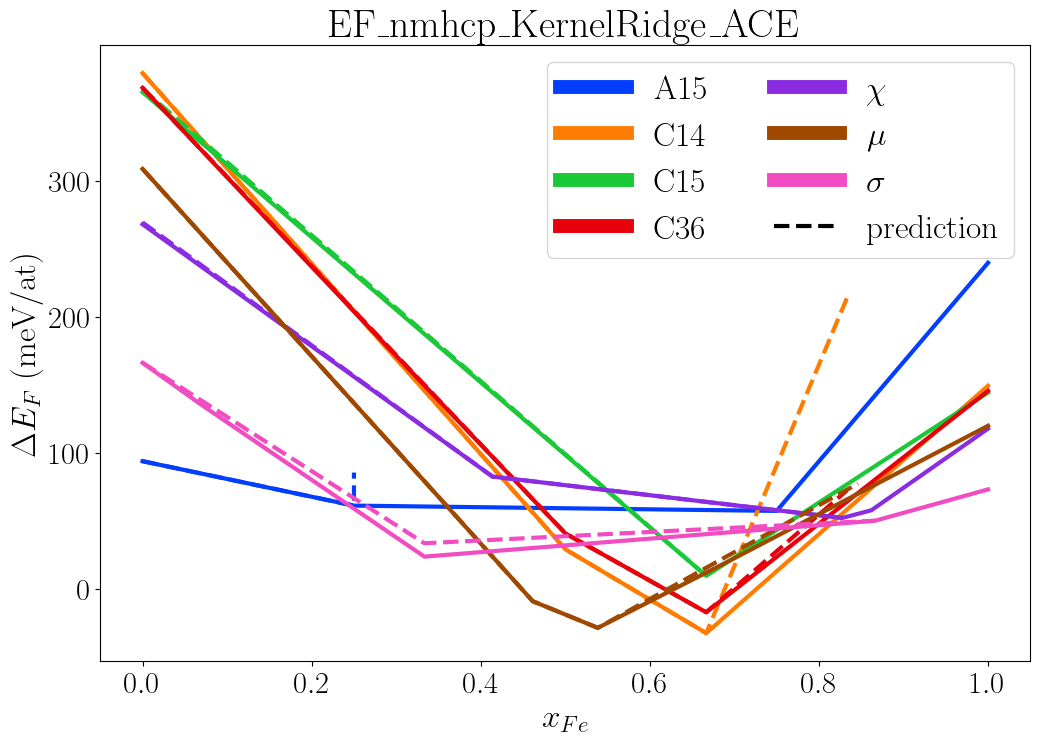

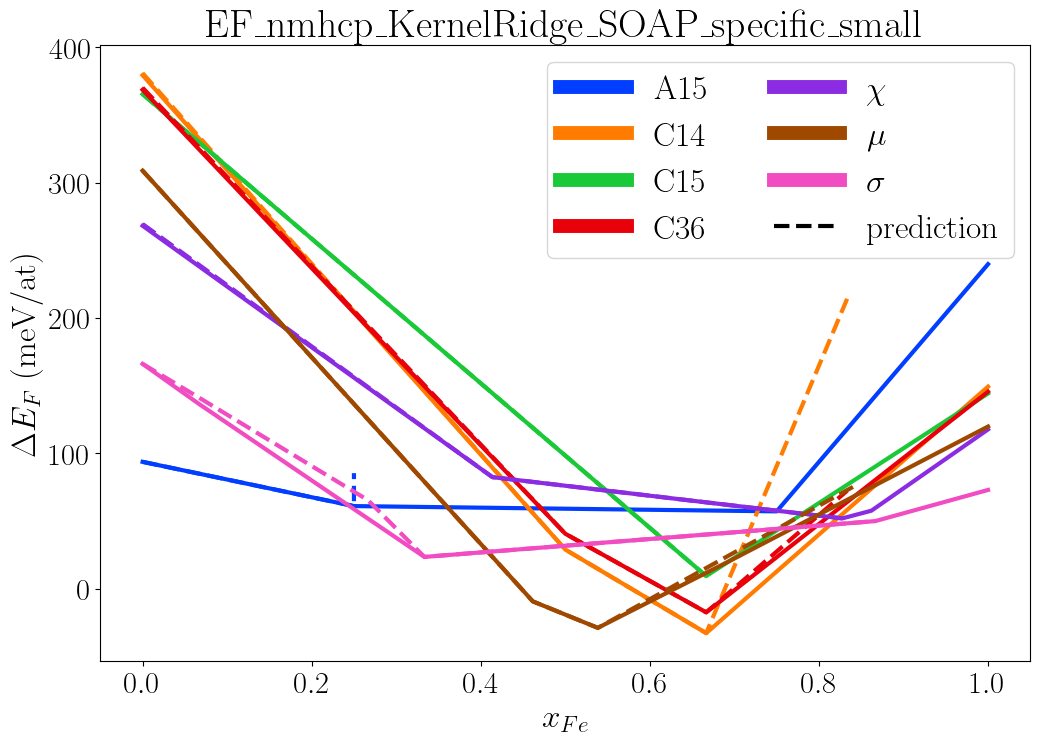

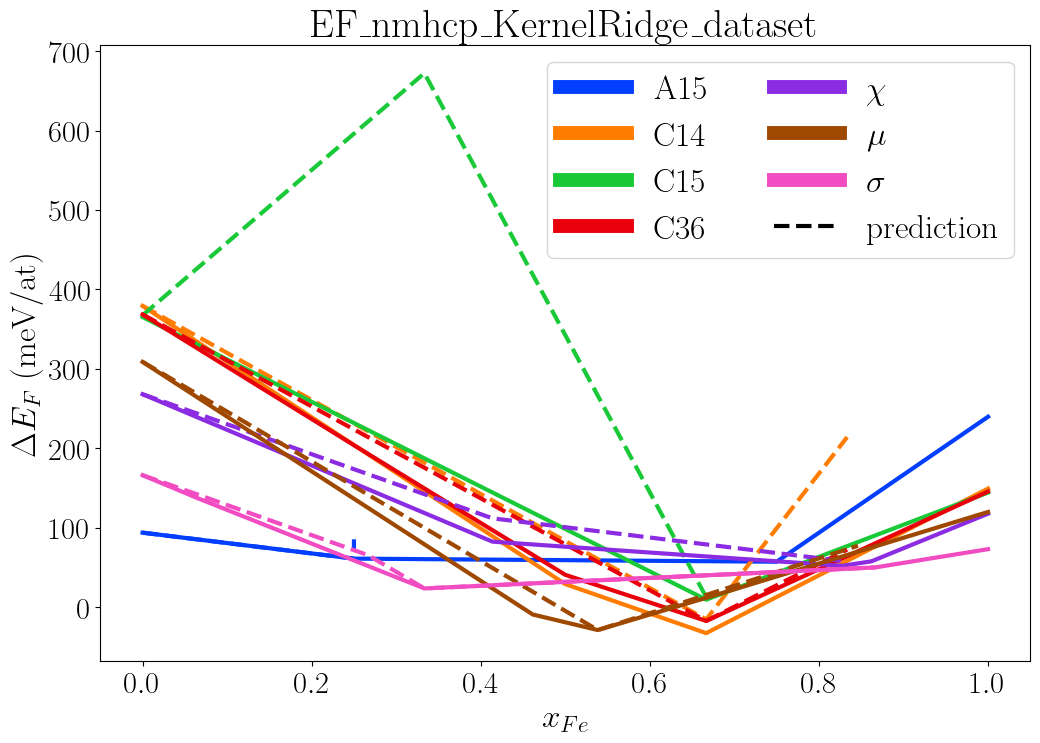

In [35]:
for predcase, pred_chull_phases in PREDICT_CHULL.items():
    fig, ax = plt.subplots(figsize=(12, 8))
    handles = []
    for i, (phase, pred_chull) in enumerate(pred_chull_phases.items()):
        if phase in ['bcc', 'fcc', 'hcp', 'R']:
            continue
        pred_bs_phase = predictionBS[predictionBS.Phase == phase]
        vertices = np.unique(pred_chull.simplices[pred_chull.good])
        pred_xy_chull = pred_bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
        ax.plot(
            pred_xy_chull['Fe_pv'].values,  pred_xy_chull[target_case].values * 1000,      '--',  color = colors[i] )
        ax.plot(
            xy_chull[phase]['Fe_pv'].values, xy_chull[phase][target_case].values*1000,     color = colors[i], )
        handles.append(Line2D([],[], linestyle='-', linewidth=10, color=colors[i], label=make_phase_label(phase)))
    ax.set_title(predcase)
    ax.set_xlabel(r'$x_{Fe}$')
    ax.set_ylabel(r'$\Delta E_F$ (meV/at)')
    handles.append(Line2D([], [], linestyle='--', color='k',  label = 'prediction'))
    ax.legend(handles=handles, ncols=2)

    filename = os.path.join(convexull_plots_loc, f'{dataset}_{prediction_name}_CHULL_only.pdf')
    fig.savefig(filename)


# Error on phases

In [36]:
phase_predictionBS.keys()

dict_keys(['A15', 'C14', 'C15', 'C36', 'chi', 'mu', 'sigma'])

In [37]:
phase_Err = {}

In [38]:
for (modelname, featurename), err in Err.items():
    phase_Err[(modelname, featurename)]= {} # err[phase_bs.index]
    for phase, phase_bs  in phase_predictionBS.items():
        intersection = err.index.intersection(phase_bs.index)
        phase_Err[(modelname, featurename)].update({phase : err[intersection]})

In [39]:
boxplot_loc = os.path.join(dataset, 'graphs', 'error_boxplots')
if not os.path.exists(boxplot_loc):
    os.makedirs(boxplot_loc)

In [40]:
from matplotlib.ticker import LogFormatterSciNotation, LogFormatter, ScalarFormatter, LogitFormatter

/tmp/ipykernel_96181/2330024235.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  theplot = ax.boxplot(x=phase_err.values(), labels=[make_phase_label(phasename) for phasename in phase_err.keys()])#, whis=0.75)
/tmp/ipykernel_96181/2330024235.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  theplot = ax.boxplot(x=phase_err.values(), labels=[make_phase_label(phasename) for phasename in phase_err.keys()])#, whis=0.75)
/tmp/ipykernel_96181/2330024235.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  theplot = ax.boxplot(x=phase_err.values(), labels=[make_phase_label(phasename) for phasename in phase_err.keys()])#, 

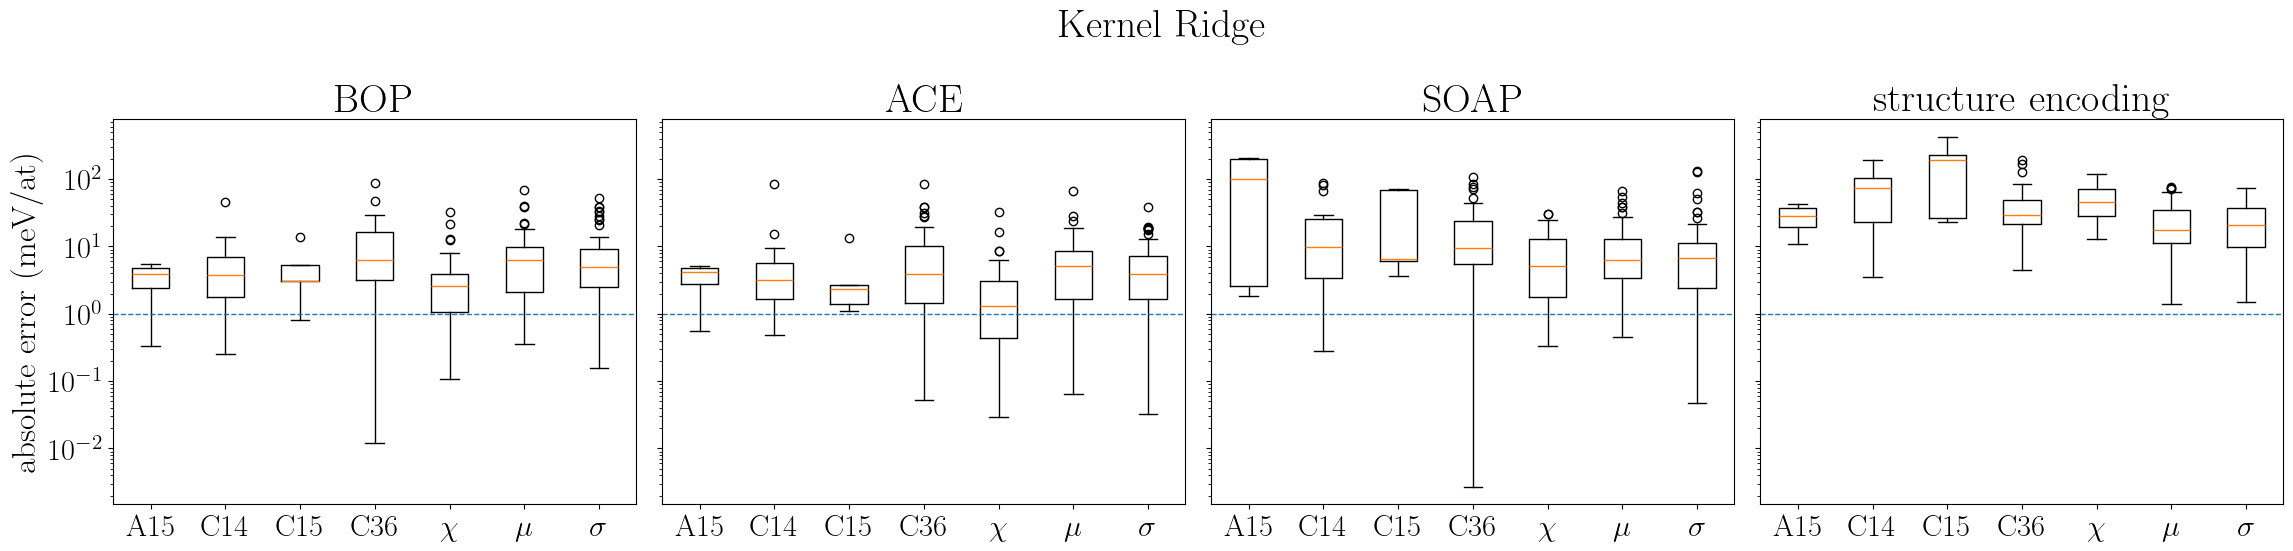

In [41]:
fig, axes = plt.subplots(1,len(Err), sharey=True, figsize=[plt.rcParams['figure.figsize'][0]*len(Err), plt.rcParams['figure.figsize'][1]])
plt.subplots_adjust(wspace=0.05)
for ax, ((modelname, featurename), phase_err) in zip(axes, phase_Err.items()):
    theplot = ax.boxplot(x=phase_err.values(), labels=[make_phase_label(phasename) for phasename in phase_err.keys()])#, whis=0.75)
    ax.axhline(1, linestyle='--', linewidth=1)
    ax.set_yscale('log')
    ax.set_title(make_feature_labels(featurename))
axes[0].yaxis.set_major_formatter(LogFormatterSciNotation())
ylabel = axes[0].set_ylabel('absolute error (meV/at)')
fig.suptitle(ModelName, y=1.1)
filename = os.path.join(boxplot_loc, f'{dataset}_{ModelName}_boxplot.pdf')
fig.savefig(filename)

In [42]:

for combi, err in Err.items():
    err.name = 'Absolute Error'
    Err[combi] = pd.concat([err, DS.StructureNames, DS.BS.Mag], axis = 1).dropna()
    Err[combi] = Err[combi][~Err[combi].index.str.contains('R')]

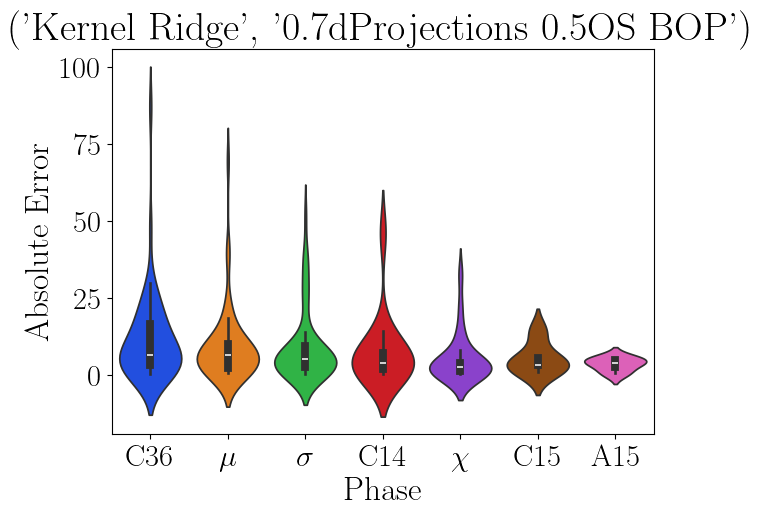

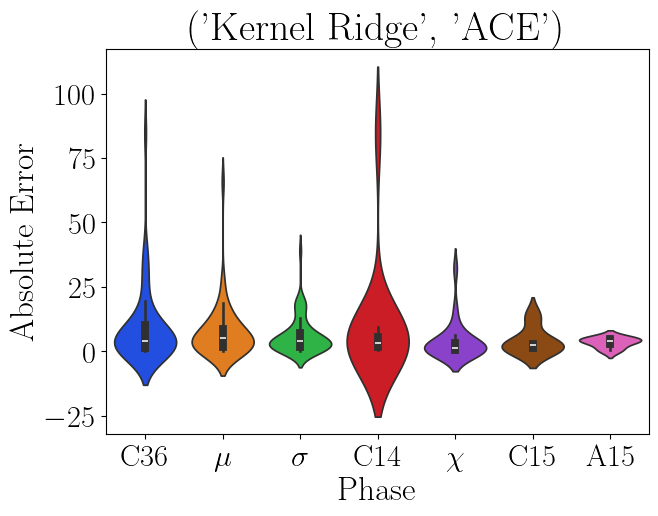

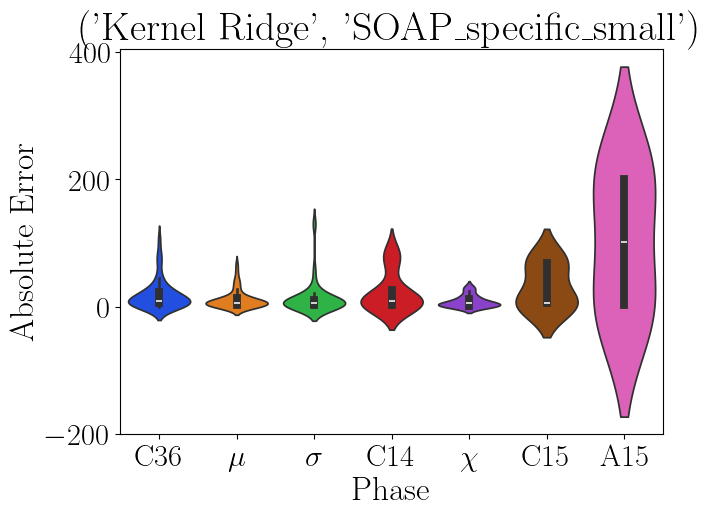

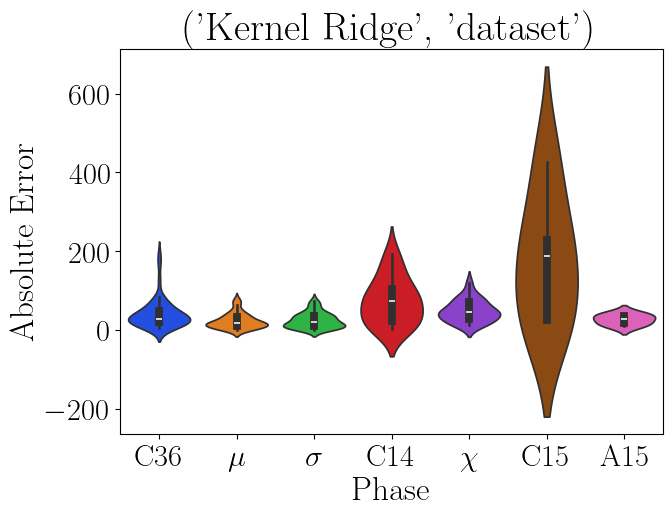

In [43]:
for keycombi, err in Err.items():
    fig, ax = plt.subplots()
    sns.violinplot(
        x='Phase',
        y='Absolute Error',
        data=err,
        hue='Phase',
        ax=ax,
        palette=colors,
        legend=False,
    )
    ax.set_title(keycombi)
    phase_ticks = [tick.get_text() for tick in ax.get_xticklabels()]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels([make_phase_label(phase) for phase in phase_ticks])